In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score, roc_auc_score,
    precision_score, recall_score,
    classification_report, confusion_matrix
)
import joblib

In [2]:
df = pd.read_csv("creditcard.csv")

print("Shape:", df.shape)
print("\nClass distribution:")
print(df["Class"].value_counts())
print(f"\nFraud rate: {df['Class'].mean()*100:.2f}%")

Shape: (284807, 31)

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud rate: 0.17%


In [3]:
FEATURES = [c for c in df.columns if c not in ["Class", "day"]]
X = df[FEATURES]
y = df["Class"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nTrain size: {len(X_train)} | Test size: {len(X_test)}")


Train size: 227845 | Test size: 56962


In [5]:
clf = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",   # handles class imbalance automatically
    random_state=42,
    n_jobs=-1
)
clf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [6]:
y_pred  = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

baseline_metrics = {
    "F1":        f1_score(y_test, y_pred),
    "AUC-ROC":   roc_auc_score(y_test, y_proba),
    "Precision": precision_score(y_test, y_pred),
    "Recall":    recall_score(y_test, y_pred),
}

print("\n── Baseline Metrics ──────────────────")
for k, v in baseline_metrics.items():
    print(f"  {k:<12}: {v:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Legit", "Fraud"]))



── Baseline Metrics ──────────────────
  F1          : 0.8391
  AUC-ROC     : 0.9529
  Precision   : 0.9605
  Recall      : 0.7449

Classification Report:
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962



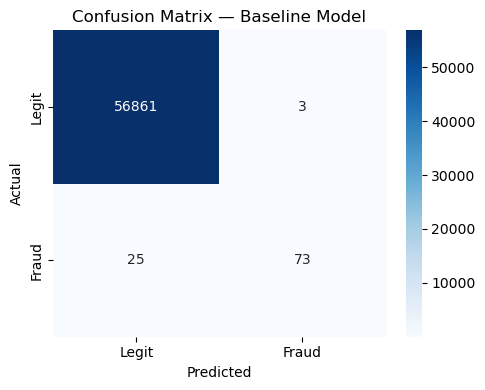

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Legit", "Fraud"],
            yticklabels=["Legit", "Fraud"])
plt.title("Confusion Matrix — Baseline Model")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()


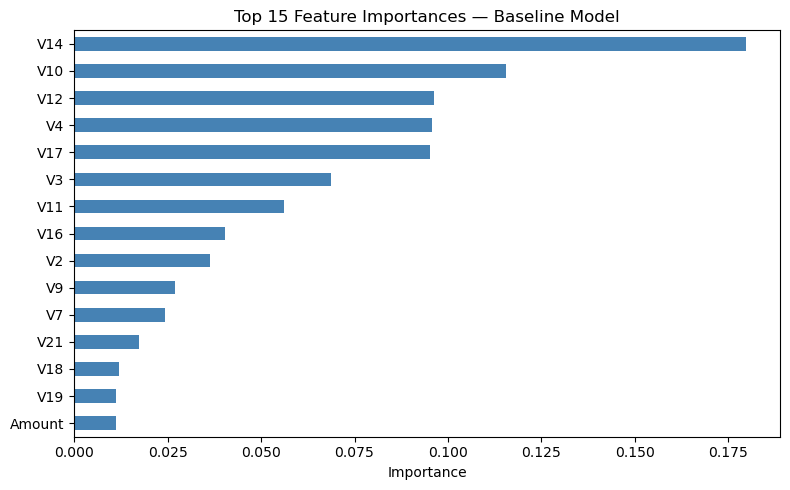

In [ ]:
importances = pd.Series(clf.feature_importances_, index=FEATURES)
top15 = importances.nlargest(15)

plt.figure(figsize=(8, 5))
top15.sort_values().plot(kind="barh", color="steelblue")
plt.title("Top 15 Feature Importances — Baseline Model")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [9]:
joblib.dump(clf, "baseline_model.pkl")
joblib.dump(FEATURES, "feature_list.pkl")

baseline_df = pd.DataFrame([baseline_metrics])
baseline_df.to_csv("baseline_metrics.csv", index=False)

print("\nModel saved to baseline_model.pkl")
print("Metrics saved to baseline_metrics.csv")


Model saved to baseline_model.pkl
Metrics saved to baseline_metrics.csv
